<a href="https://colab.research.google.com/github/code-pyro1/code-pyro1/blob/main/DiabetesClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
#load dataset
df=pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
X= df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].values
y= df['Outcome'].values

In [22]:

preg_mean=df['Pregnancies'].mean()
glucose_mean = df['Glucose'].mean()
BP=df['BloodPressure'].mean()
SKin=df['SkinThickness'].mean()
insulin=df['Insulin'].mean()
bmi=df['BMI'].mean()
DPF=df['DiabetesPedigreeFunction'].mean
age=df['Age'].mean()
print(preg_mean,glucose_mean, BP, SKin, insulin, bmi, DPF, age)


3.8450520833333335 120.89453125 69.10546875 20.536458333333332 79.79947916666667 31.992578124999998 <bound method Series.mean of 0      0.627
1      0.351
2      0.672
3      0.167
4      2.288
       ...  
763    0.171
764    0.340
765    0.245
766    0.349
767    0.315
Name: DiabetesPedigreeFunction, Length: 768, dtype: float64> 33.240885416666664


In [20]:
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(X,y)
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [26]:
X_new= np.array([[4,120,69,20,80,32,0.627,33]])
prediction=knn.predict(X_new)
if prediction[0] == 0:
    print(prediction,'This patient might not have diabetes')
else:
    print( prediction, 'This patient might have diabetes')


[0] This patient might not have diabetes


**To check for model performance**

In [31]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=27, stratify=y)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [33]:
print(knn.score(X_test, y_test))

0.7532467532467533


In [37]:
training_accuracies={}
test_accuracies={}
neighbors=np.arange(1,26)
for k in neighbors:
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  training_accuracies[k]=knn.score(X_train, y_train)
  test_accuracies[k]=knn.score(X_test, y_test)
for k in neighbors:
    print(f"K={k}, Training: {training_accuracies[k]:.4f}, Testing: {test_accuracies[k]:.4f}")

K=1, Training: 1.0000, Testing: 0.6970
K=2, Training: 0.8324, Testing: 0.7359
K=3, Training: 0.8492, Testing: 0.7532
K=4, Training: 0.8007, Testing: 0.7403
K=5, Training: 0.8045, Testing: 0.7403
K=6, Training: 0.7858, Testing: 0.7403
K=7, Training: 0.7914, Testing: 0.7532
K=8, Training: 0.7821, Testing: 0.7706
K=9, Training: 0.7765, Testing: 0.7706
K=10, Training: 0.7654, Testing: 0.7576
K=11, Training: 0.7672, Testing: 0.7706
K=12, Training: 0.7598, Testing: 0.7619
K=13, Training: 0.7561, Testing: 0.7749
K=14, Training: 0.7523, Testing: 0.7706
K=15, Training: 0.7523, Testing: 0.7835
K=16, Training: 0.7561, Testing: 0.7706
K=17, Training: 0.7542, Testing: 0.7576
K=18, Training: 0.7542, Testing: 0.7662
K=19, Training: 0.7505, Testing: 0.7706
K=20, Training: 0.7486, Testing: 0.7619
K=21, Training: 0.7486, Testing: 0.7662
K=22, Training: 0.7467, Testing: 0.7619
K=23, Training: 0.7598, Testing: 0.7532
K=24, Training: 0.7486, Testing: 0.7749
K=25, Training: 0.7486, Testing: 0.7749


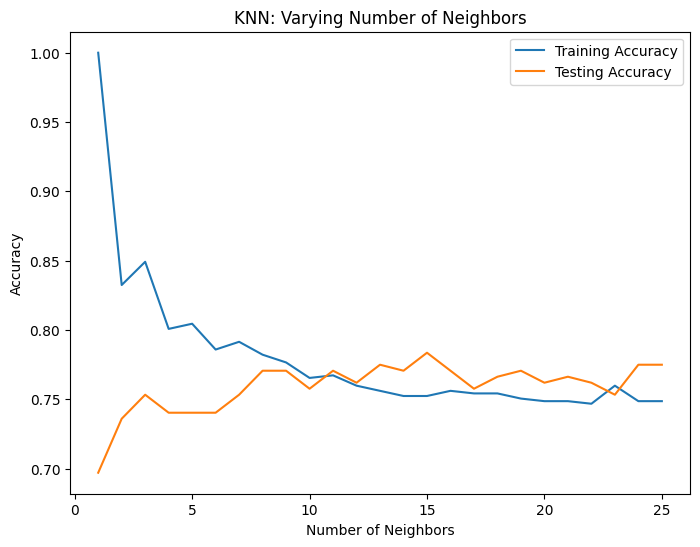

In [38]:
#plot
plt.figure(figsize=(8, 6))
plt.title("KNN: Varying Number of Neighbors")
plt.plot(neighbors, training_accuracies.values(), label="Training Accuracy")
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()